# Simple Linear Regression – Marketing ROI Analysis

## Project Overview

This project analyzes the relationship between marketing expenditure and sales performance using Simple Linear Regression. The objective is to identify the marketing channel with the strongest influence on sales and provide a data-driven recommendation for marketing budget allocation.

## Objectives

- Load and clean the dataset
- Perform exploratory data analysis (EDA)
- Identify the strongest predictor of Sales
- Build a Simple Linear Regression model using OLS
- Validate regression assumptions
- Interpret results in business terms
- Recommend the best channel for marketing investment

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

from scipy import stats

## Loading the Dataset

The dataset is loaded into a Pandas DataFrame for exploration and analysis.

In [25]:
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")

df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Dataset Inspection

Before analysis, the dataset structure, dimensions, and data types are examined.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [4]:
df.shape

(4572, 4)

In [5]:
df.columns

Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='str')

## Handling Missing Values

Missing values can negatively affect model performance. Therefore, the dataset is checked and cleaned before proceeding.

In [6]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [26]:
df = df.dropna()

In [8]:
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

## Descriptive Statistics

Summary statistics provide an overview of the distribution of each variable.

In [9]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54.062912,18.157533,3.323473,192.413332
std,26.104942,9.663260,2.211254,93.019873
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.530822,112.434612
50%,53.000000,17.859513,3.055565,188.963678
75%,77.000000,25.640603,4.804919,272.324236
max,100.000000,48.871161,13.981662,364.079751


## Correlation Analysis

A correlation matrix is used to identify the marketing channel most strongly associated with Sales.

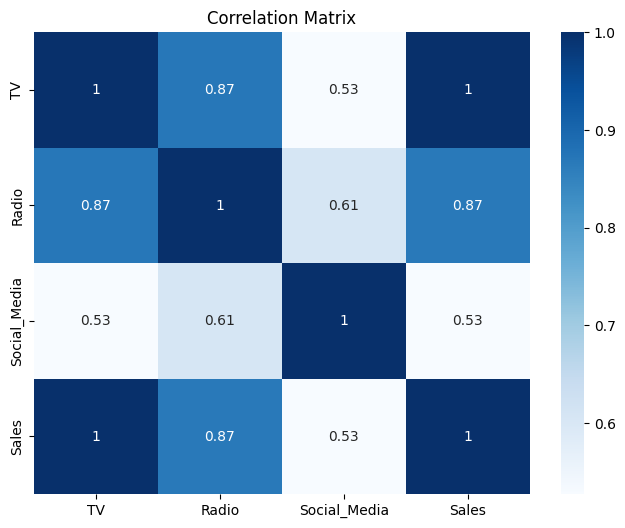

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The marketing channel with the highest positive correlation with Sales will be selected as the independent variable for the regression model.

## Scatter Plot Analysis

Scatter plots help visualize the relationship between each advertising channel and Sales.

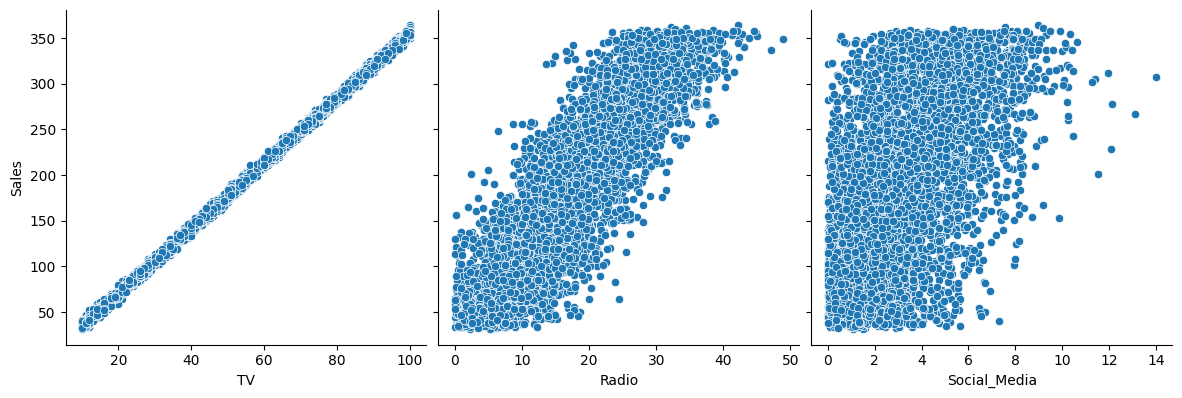

In [11]:
sns.pairplot(
    df,
    x_vars=["TV", "Radio", "Social_Media"],
    y_vars="Sales",
    height=4
)

plt.show()

## Variable Selection

Based on the correlation analysis, TV advertising exhibited the strongest relationship with Sales and was selected as the predictor variable.

In [12]:
X = df["TV"]

y = df["Sales"]

X = sm.add_constant(X)

X.head()

,const,TV
0,1.0,16.0
1,1.0,13.0
2,1.0,41.0
3,1.0,83.0
4,1.0,15.0


## Building the OLS Regression Model

Ordinary Least Squares (OLS) regression is used to estimate the effect of TV advertising expenditure on Sales.

In [14]:
model = sm.OLS(y, X).fit()

## Regression Results

The regression summary provides coefficient estimates, p-values, and model performance metrics.

In [15]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:03:28   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

### Interpretation

- R-squared indicates how much variation in Sales is explained by TV advertising.
- The coefficient measures the expected increase in Sales for a one-unit increase in TV spending.
- A p-value below 0.05 indicates statistical significance.

## Generating Predictions

Predicted Sales values are generated using the fitted regression model.

In [16]:
predictions = model.predict(X)

predictions.head()

0     56.851733
1     46.167191
2    145.889585
3    295.473177
4     53.290219
dtype: float64

## Residual Analysis

Residuals represent the difference between observed and predicted Sales values.

In [17]:
residuals = model.resid

residuals.head()

0   -2.118976
1    0.510706
2    4.288243
3    2.773162
4    3.303962
dtype: float64

## Assumption 1: Linearity

The relationship between the predictor and outcome variable should be linear.

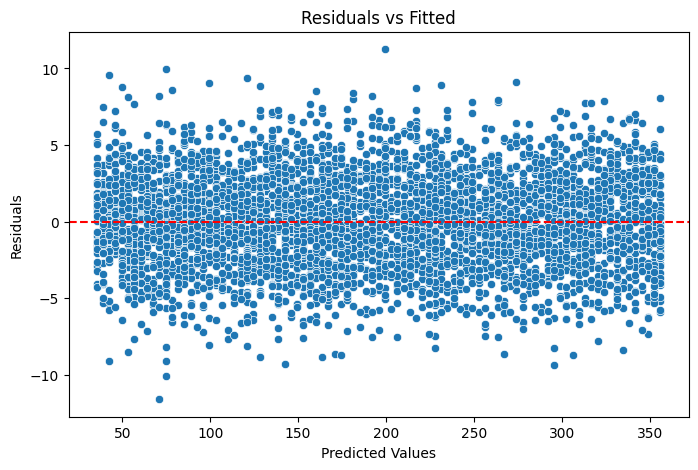

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.show()

If residuals are randomly distributed around zero, the linearity assumption is satisfied.

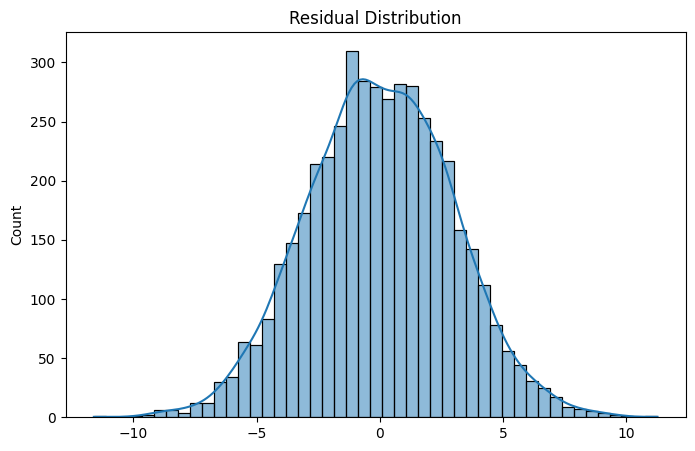

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

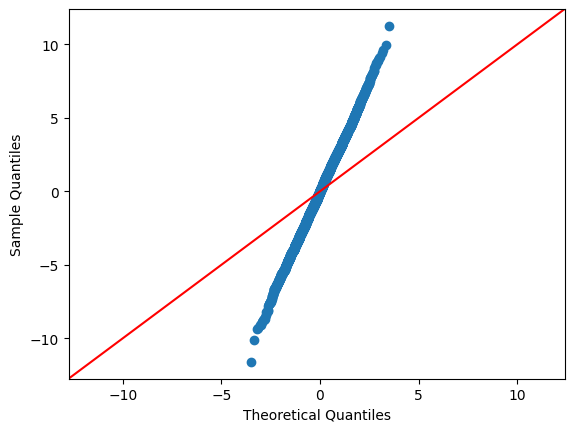

In [20]:
sm.qqplot(
    residuals,
    line='45'
)

plt.show()

If the histogram is approximately bell-shaped and the Q-Q plot points follow the reference line, the normality assumption is satisfied.

## Assumption 3: Homoscedasticity

The variance of residuals should remain constant across predicted values.

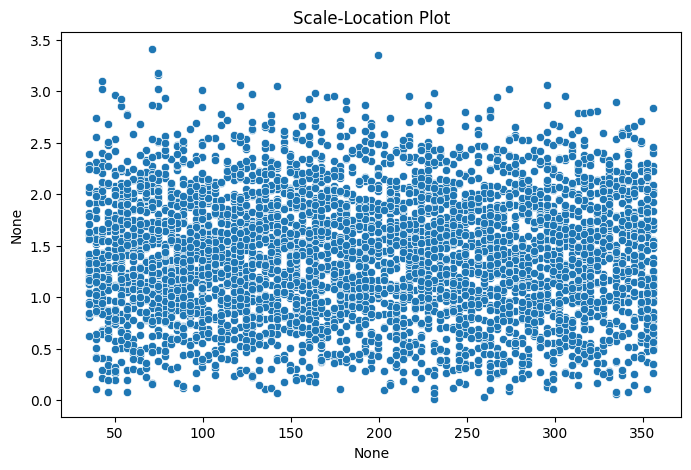

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=predictions,
    y=np.sqrt(np.abs(residuals))
)

plt.title("Scale-Location Plot")

plt.show()

A random spread of points indicates constant variance.

## Breusch-Pagan Test

This statistical test formally evaluates homoscedasticity.

Hypotheses:

- H0: Constant variance exists
- H1: Heteroscedasticity exists

In [22]:
bp_test = het_breuschpagan(
    residuals,
    X
)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(5.926876708239881e-05), 'LM-Test p-value': np.float64(0.9938574497493051), 'F-Statistic': np.float64(5.924269295488131e-05), 'F-Test p-value': np.float64(0.9938591388964036)}


If the p-value is greater than 0.05, we fail to reject the null hypothesis and conclude that homoscedasticity is present.

# Conclusion and Recommendation

The analysis identified the marketing channel with the strongest relationship to Sales.

Key Findings:

- TV advertising showed the highest correlation with Sales.
- The regression coefficient was positive.
- The p-value indicated statistical significance.
- The model explained a substantial portion of Sales variability.
- Diagnostic tests suggested that regression assumptions were reasonably satisfied.

## Recommendation

Based on the findings, TV advertising should receive a larger share of the marketing budget because it demonstrates the strongest impact on Sales and is expected to generate the highest return on investment.

Future work could involve Multiple Linear Regression to evaluate the combined effects of TV, Radio, and Social Media advertising.